# CEdit: train/infer `legacy` vs `shared_residual` và đánh giá bằng CE-Eval

Notebook này tái hiện bài toán xóa 10 celebrity trong `CEdit/docs/SPEED.md`, tạo hai checkpoint riêng, sinh ảnh `erase`/`retain`, rồi chạy GIPHY Celebrity Detector (GCD) từ CE-Eval.

> Trước khi chạy: vào **Runtime → Change runtime type → T4 GPU**. Một lượt benchmark đầy đủ có **500 erase + 500 retain ảnh cho mỗi model**. `sample2.py` hiện không dùng giá trị `--num_samples`, nên tham số đó không thể thu nhỏ benchmark. Để chỉ chạy một split trước, đặt `CONTENTS = ("erase",)` ở cell cấu hình.

In [1]:
# Kiểm tra GPU Colab
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader

import torch
assert torch.cuda.is_available(), "Hãy bật GPU runtime trước khi tiếp tục."
print("PyTorch:", torch.__version__, "| CUDA:", torch.version.cuda)

NVIDIA A100-SXM4-40GB, 40960 MiB, 40442 MiB
PyTorch: 2.11.0+cu128 | CUDA: 12.8


## 1. Clone đúng hai codebase đã được kiểm tra

`CEdit` được clone trực tiếp từ branch `feat/shared-residual-anchor` để có cả hai mode. `CE-Eval` được pin tại commit đã kiểm tra để pipeline đánh giá giữ nguyên hành vi.

In [1]:
%%bash
set -Eeuo pipefail
cd /content

# CEDIT_BRANCH="feat/shared-residual-anchor"
CEDIT_BRANCH="main"

if [[ ! -d CEdit/.git ]]; then
  git clone --branch "${CEDIT_BRANCH}" --single-branch https://github.com/izahai/CEdit.git CEdit
else
  git -C CEdit fetch origin "${CEDIT_BRANCH}:refs/remotes/origin/${CEDIT_BRANCH}"
fi
if [[ ! -d CE-Eval/.git ]]; then
  git clone https://github.com/izahai/CE-Eval.git
fi

git -C CEdit checkout "${CEDIT_BRANCH}" 2>/dev/null || \
  git -C CEdit checkout --track -b "${CEDIT_BRANCH}" "origin/${CEDIT_BRANCH}"
git -C CEdit merge --ff-only "origin/${CEDIT_BRANCH}"
git -C CE-Eval fetch origin
git -C CE-Eval checkout 5322a63

printf 'CEdit:  '; git -C CEdit branch --show-current; printf ' @ '; git -C CEdit rev-parse --short HEAD
printf 'CE-Eval: '; git -C CE-Eval rev-parse --short HEAD

Your branch is up to date with 'origin/main'.
Already up to date.
CEdit:  main
 @ 0d7584b
CE-Eval: 5322a63


Cloning into 'CEdit'...
Cloning into 'CE-Eval'...
Note: switching to '5322a63'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 5322a63 fix(gcd): support sanitized celebrity image filenames


In [2]:
# CEdit không pin lại torch, nên giữ nguyên bản PyTorch/CUDA tối ưu sẵn của Colab.
%pip install -q -r /content/CEdit/requirements.txt
%pip install -q python-dotenv openpyxl scikit-image scikit-learn opencv-python-headless

# TensorFlow có sẵn trong Colab và chỉ được CE-Eval dùng cho MTCNN face detector.
import tensorflow as tf
print("TensorFlow:", tf.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 165.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 109.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
TensorFlow: 2.20.0


Nếu Hugging Face yêu cầu token để tải Stable Diffusion v1.4, tạo Colab secret tên `HF_TOKEN`. Cell dưới đây không in token ra output.

In [ ]:
try:
    from google.colab import userdata
    from huggingface_hub import login
    hf_token = userdata.get("HF_TOKEN")
    if hf_token:
        login(token=hf_token, add_to_git_credential=False)
        print("Đã đăng nhập Hugging Face.")
    else:
        print("Không có HF_TOKEN; tiếp tục bằng truy cập công khai/cache.")
except Exception as exc:
    print("Bỏ qua đăng nhập Hugging Face:", type(exc).__name__)

## 2. Cấu hình thí nghiệm

- `legacy`: thống kê anchor–target riêng theo từng cặp celebrity → person.
- `shared_residual`: dùng một residual chung `mean(anchor) - mean(target)` cho cả 10 celebrity.
- `FORCE_RETRAIN/FORCE_RESAMPLE = False` giúp chạy lại notebook mà không lặp công việc đã hoàn tất.
- `RUN_ORIGINAL = True` nếu muốn thêm baseline SD v1.4 chưa edit; so sánh hai mode thì không bắt buộc.

In [3]:
from pathlib import Path
import os, subprocess, pandas as pd

CEDIT = Path("/content/CEdit")
CEEVAL = Path("/content/CE-Eval")
OUTPUT_ROOT = Path("/content/cedit_ce_eval_outputs")
SD_CKPT = "CompVis/stable-diffusion-v1-4"

BENCHMARK_NAME = "10_celebrity"
TARGET_CONCEPTS = (
    "Adam Driver, Adriana Lima, Amber Heard, Amy Adams, Andrew Garfield, "
    "Angelina Jolie, Anjelica Huston, Anna Faris, Anna Kendrick, Anne Hathaway"
)
ANCHOR_CONCEPTS = "person"
# ANCHOR_MODES = ("legacy", "shared_residual_max_norm")
ANCHOR_MODES = ("legacy", "shared_residual_max_norm", "shared_residual_cosine_medoid", "shared_residual_smallest_cosine_medoid")
RESIDUAL_SCALE = 1.0
CONTENTS = ("erase", "retain")  # smoke test nhanh: ("erase",)
BATCH_SIZE = 10
FORCE_RETRAIN = False
FORCE_RESAMPLE = False
RUN_ORIGINAL = True
GCD_USE_CUDA = True  # CPU an toàn hơn: tránh TensorFlow và PyTorch tranh VRAM

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
benchmark = pd.read_csv(CEDIT / f"data/{BENCHMARK_NAME}.csv")
expected_counts = benchmark.groupby("type").size().to_dict()
print("Số ảnh benchmark mỗi model:", expected_counts)
print("Output:", OUTPUT_ROOT)

Số ảnh benchmark mỗi model: {'erase': 500, 'retain': 500}
Output: /content/cedit_ce_eval_outputs


Nếu muốn giữ checkpoint/ảnh qua lần reset Colab, mount Drive rồi đổi `OUTPUT_ROOT`, ví dụ `Path('/content/drive/MyDrive/CEdit-CE-Eval')`, trước khi chạy các cell tiếp theo.

In [ ]:
# Tùy chọn Google Drive (bỏ comment nếu cần)
# from google.colab import drive
# drive.mount('/content/drive')
# OUTPUT_ROOT = Path('/content/drive/MyDrive/CEdit-CE-Eval')
# OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

## 3. Train hai checkpoint

Các tham số giữ đúng lệnh trong `CEdit/docs/SPEED.md`: retain scale 0.05, tắt filter, retain set `data/10_celebrity.csv`, cột `concept`. Chỉ thêm `--anchor_mode` và đường dẫn output rõ ràng.

In [4]:
import os
import subprocess
import sys

def run_checked(args, cwd=CEDIT, env_extra=None):
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = "0"
    env["PYTHONUNBUFFERED"] = "1"
    if env_extra:
        env.update({k: str(v) for k, v in env_extra.items()})

    command = [str(x) for x in args]
    print("\n" + "=" * 80, flush=True)
    print("$", " ".join(command), flush=True)
    print("=" * 80, flush=True)

    # Sử dụng Popen để đọc log theo thời gian thực
    process = subprocess.Popen(
        command,
        cwd=str(cwd),
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )

    # In từng dòng ngay khi nhận được
    for line in process.stdout:
        print(line, end="", flush=True)

    process.wait()
    if process.returncode != 0:
        raise subprocess.CalledProcessError(process.returncode, command)

checkpoint_paths = {}

_ANCHOR_MODES_ITERABLE = (
    [ANCHOR_MODES]
    if isinstance(ANCHOR_MODES, str)
    else ANCHOR_MODES
)

for anchor_mode in _ANCHOR_MODES_ITERABLE:
    save_dir = OUTPUT_ROOT / "checkpoints" / anchor_mode
    ckpt = save_dir / "weight.pt"
    checkpoint_paths[anchor_mode] = ckpt

    if ckpt.exists() and not FORCE_RETRAIN:
        print(f"[SKIP] Đã tồn tại checkpoint cho {anchor_mode}: {ckpt}", flush=True)
        continue

    save_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n[TRAIN] Bắt đầu train anchor mode: {anchor_mode}", flush=True)

    run_checked([
        "python",
        "-u",
        "train_erase_null.py",
        "--sd_ckpt", SD_CKPT,
        "--target_concepts", TARGET_CONCEPTS,
        "--anchor_concepts", ANCHOR_CONCEPTS,
        "--anchor_mode", anchor_mode,
        "--retain_scale", "0.05",
        "--disable_filter",
        "--aug_num", "0",
        "--retain_path", f"data/{BENCHMARK_NAME}.csv",
        "--heads", "concept",
        "--save_path", save_dir,
        "--file_name", "weight",
        "--residual_scale", RESIDUAL_SCALE,
    ])

    assert ckpt.is_file(), f"Không tìm thấy checkpoint: {ckpt}"
    print(f"[DONE] Hoàn thành {anchor_mode}", flush=True)

checkpoint_paths


[TRAIN] Bắt đầu train anchor mode: legacy

$ python -u train_erase_null.py --sd_ckpt CompVis/stable-diffusion-v1-4 --target_concepts Adam Driver, Adriana Lima, Amber Heard, Amy Adams, Andrew Garfield, Angelina Jolie, Anjelica Huston, Anna Faris, Anna Kendrick, Anne Hathaway --anchor_concepts person --anchor_mode legacy --retain_scale 0.05 --disable_filter --aug_num 0 --retain_path data/10_celebrity.csv --heads concept --save_path /content/cedit_ce_eval_outputs/checkpoints/legacy --file_name weight --residual_scale 1.0
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.

0it [00:00, ?it/s]
0it [00:00, ?it/s]

Fetching 16 files: 100%|██████████| 16/16 [00:14<00:00,  1.12it/s]

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.30it/s]
running k-means on cuda..

[running kmeans]: 0it [00:00, 

{'legacy': PosixPath('/content/cedit_ce_eval_outputs/checkpoints/legacy/weight.pt'),
 'shared_residual_max_norm': PosixPath('/content/cedit_ce_eval_outputs/checkpoints/shared_residual_max_norm/weight.pt'),
 'shared_residual_cosine_medoid': PosixPath('/content/cedit_ce_eval_outputs/checkpoints/shared_residual_cosine_medoid/weight.pt'),
 'shared_residual_smallest_cosine_medoid': PosixPath('/content/cedit_ce_eval_outputs/checkpoints/shared_residual_smallest_cosine_medoid/weight.pt')}

## 4. Infer ảnh `erase` và `retain`

Mỗi mode đi vào một thư mục độc lập. Cấu trúc cuối cùng là `images/<mode>/10_celebrity/<erase|retain>/edit/*.png`, đúng yêu cầu CE-Eval rằng folder truyền vào chỉ chứa file ảnh, không chứa thư mục con.

In [5]:
def image_folder(model_name, content, sample_mode="edit"):
    return OUTPUT_ROOT / "images" / model_name / BENCHMARK_NAME / content / sample_mode

def png_count(folder):
    return len(list(folder.glob("*.png"))) if folder.exists() else 0

for anchor_mode, ckpt in checkpoint_paths.items():
    assert ckpt.is_file(), f"Thiếu checkpoint: {ckpt}"
    for content in CONTENTS:
        out = image_folder(anchor_mode, content)
        expected = expected_counts[content]
        if png_count(out) == expected and not FORCE_RESAMPLE:
            print(f"Skip infer {anchor_mode}/{content}: đủ {expected} ảnh")
            continue
        run_checked([
            "python", "sample2.py",
            "--sd_ckpt", SD_CKPT,
            "--erase_type", BENCHMARK_NAME,
            "--target_concept", BENCHMARK_NAME,
            "--contents", content,
            "--mode", "edit",
            "--batch_size", str(BATCH_SIZE),
            "--save_root", OUTPUT_ROOT / "images" / anchor_mode,
            "--edit_ckpt", ckpt,
        ])
        actual = png_count(out)
        assert actual == expected, f"{out}: cần {expected}, hiện có {actual}"

if RUN_ORIGINAL:
    for content in CONTENTS:
        out = image_folder("original", content, "original")
        expected = expected_counts[content]
        if png_count(out) == expected and not FORCE_RESAMPLE:
            continue
        run_checked([
            "python", "sample2.py",
            "--sd_ckpt", SD_CKPT,
            "--erase_type", BENCHMARK_NAME,
            "--target_concept", BENCHMARK_NAME,
            "--contents", content,
            "--mode", "original",
            "--batch_size", str(BATCH_SIZE),
            "--save_root", OUTPUT_ROOT / "images" / "original",
        ])
        assert png_count(out) == expected

for mode in ANCHOR_MODES:
    print(mode, {c: png_count(image_folder(mode, c)) for c in CONTENTS})

Streaming output truncated to the last 5000 lines.
640 x prompts | edit:  50%|█████     | 10/20 [00:01<00:01,  7.04it/s]
640 x prompts | edit:  55%|█████▌    | 11/20 [00:01<00:01,  6.95it/s]
640 x prompts | edit:  60%|██████    | 12/20 [00:01<00:01,  6.97it/s]
640 x prompts | edit:  65%|██████▌   | 13/20 [00:01<00:01,  6.95it/s]
640 x prompts | edit:  70%|███████   | 14/20 [00:01<00:00,  6.94it/s]
640 x prompts | edit:  75%|███████▌  | 15/20 [00:02<00:00,  6.92it/s]
640 x prompts | edit:  80%|████████  | 16/20 [00:02<00:00,  6.91it/s]
640 x prompts | edit:  85%|████████▌ | 17/20 [00:02<00:00,  6.91it/s]
640 x prompts | edit:  90%|█████████ | 18/20 [00:02<00:00,  6.91it/s]
640 x prompts | edit:  95%|█████████▌| 19/20 [00:02<00:00,  6.90it/s]
640 x prompts | edit: 100%|██████████| 20/20 [00:02<00:00,  6.90it/s]
640 x prompts | edit: 100%|██████████| 20/20 [00:02<00:00,  7.15it/s]

650 x prompts | edit:   0%|          | 0/20 [00:00<?, ?it/s]
650 x prompts | edit:  10%|█         | 2/20 [00

In [9]:
!ls -R

.:
CEdit  cedit_ce_eval_outputs  CE-Eval  sample_data

./CEdit:
AGENTS.md  clip  docs		   sample2.py  scripts	train_erase_null.py
assets	   data  requirements.txt  sample.py   src

./CEdit/assets:
application.JPEG  teaser.JPEG

./CEdit/clip:
clip_sd14_svd_experiment.py  requirements.txt

./CEdit/data:
100_celebrity.csv  1_celebrity.csv   i2p_benchmark.csv	mscoco.csv  style.csv
10_celebrity.csv   50_celebrity.csv  instance.csv	pretrain

./CEdit/data/pretrain:
pretrain_sample.sh

./CEdit/docs:
shared_residual_anchor_plan.md	SPEED.md

./CEdit/scripts:
eval_few.sh  eval_multi.sh  eval_nudity.sh

./CEdit/src:
clip_score_cal.py  i2p_cal.py  __pycache__  template.py  utils.py

./CEdit/src/__pycache__:
template.cpython-312.pyc  utils.cpython-312.pyc

./cedit_ce_eval_outputs:
checkpoints  images

./cedit_ce_eval_outputs/checkpoints:
shared_residual_cosine_medoid

./cedit_ce_eval_outputs/checkpoints/shared_residual_cosine_medoid:
weight.pt

./cedit_ce_eval_outputs/images:
shared_residual_cosine_

### Xem nhanh một vài ảnh

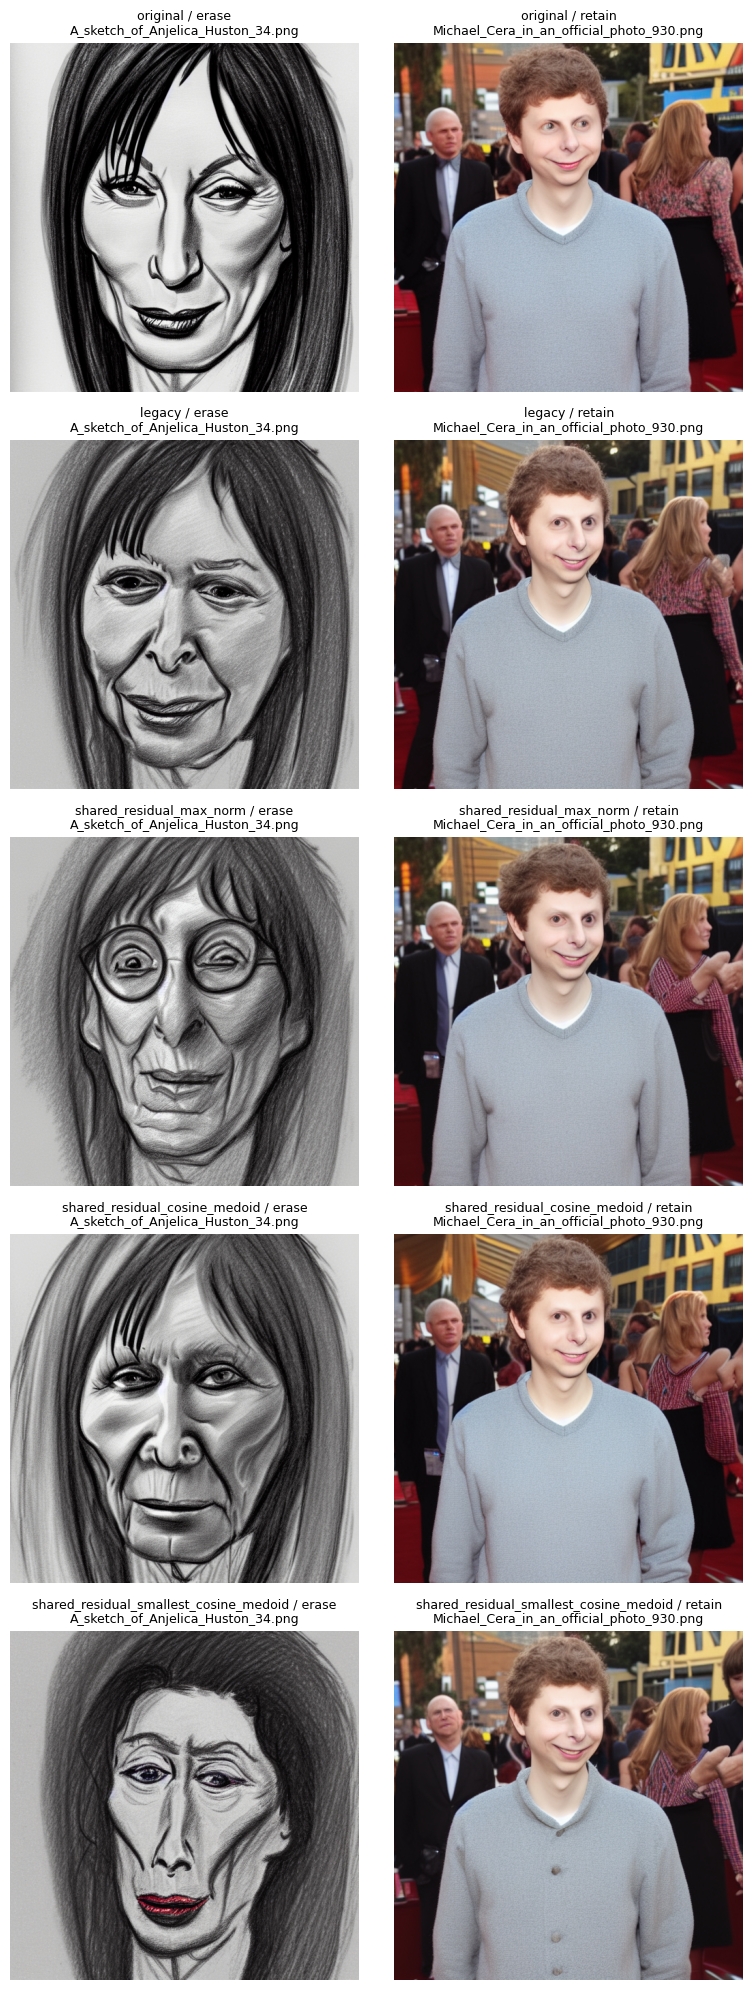

In [20]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

VIEW_SEED = 7
rng = random.Random(VIEW_SEED)

# Chỉ thêm hàng baseline khi original đã được sinh cho mọi split đang xem.
has_original = all(any(image_folder("original", content, "original").glob("*.png")) for content in CONTENTS)
VIEW_METHODS = [(mode, "edit") for mode in ANCHOR_MODES]
if has_original:
    VIEW_METHODS.insert(0, ("original", "original"))

# Chọn một filename chung cho từng split, để tất cả các hàng dùng cùng prompt/seed.
selected_files = {}
for content in CONTENTS:
    files_by_method = {
        label: {p.name: p for p in image_folder(label, content, sample_mode).glob("*.png")}
        for label, sample_mode in VIEW_METHODS
    }
    common_names = set.intersection(*(set(files) for files in files_by_method.values()))
    selected_files[content] = rng.choice(sorted(common_names)) if common_names else None

fig, axes = plt.subplots(
    len(VIEW_METHODS), len(CONTENTS),
    figsize=(4 * len(CONTENTS), 4 * len(VIEW_METHODS)),
)
axes = np.array(axes).reshape(len(VIEW_METHODS), len(CONTENTS))

for row, (label, sample_mode) in enumerate(VIEW_METHODS):
    for col, content in enumerate(CONTENTS):
        filename = selected_files[content]
        ax = axes[row, col]
        if filename is None:
            ax.set_title(f"{label} / {content}\nNo shared sample")
            ax.axis("off")
            continue
        image_path = image_folder(label, content, sample_mode) / filename
        ax.imshow(Image.open(image_path))
        ax.set_title(f"{label} / {content}\n{filename}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

Displaying 5 random images from /content/cedit_ce_eval_outputs/images/shared_residual_cosine_medoid/10_celebrity/erase:


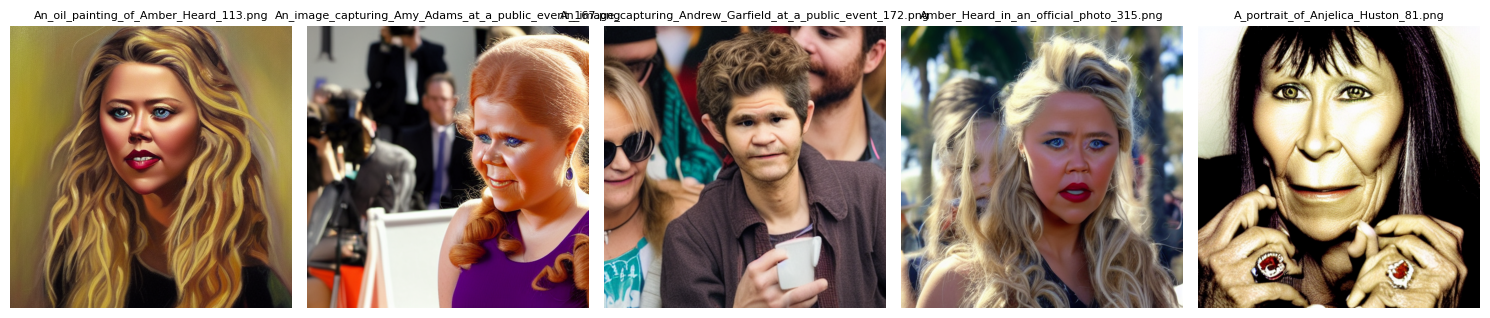

In [10]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# Define the root directory for images
image_root = OUTPUT_ROOT / "images" / "shared_residual_cosine_medoid" / "10_celebrity" / "erase"

# Find all PNG files recursively in the directory
all_image_files = list(image_root.glob('**/*.png'))

if not all_image_files:
    print(f"No PNG images found in {image_root}")
else:
    # Select a maximum of 5 random images to display
    num_images_to_display = min(5, len(all_image_files))
    selected_images = random.sample(all_image_files, num_images_to_display)

    print(f"Displaying {len(selected_images)} random images from {image_root}:")

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(selected_images):
        plt.subplot(1, num_images_to_display, i + 1)
        try:
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(img_path.name, fontsize=8)
            plt.axis('off')
        except Exception as e:
            plt.title(f"Error loading {img_path.name}\n{e}", fontsize=8)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

## 5. Chuẩn bị GIPHY Celebrity Detector

CE-Eval đã chứa detector và script tải `resources.tar.gz`. Không cài bộ requirements năm 2018 của upstream (`torch 0.4`, TensorFlow 1.15, NumPy 1.15) vì chúng không tương thích Python hiện tại của Colab; notebook dùng các package hiện đại đã có, cùng hai compatibility patch nhỏ không làm đổi metric.

In [6]:
# PyTorch >=2.6 mặc định weights_only=True; checkpoint GIPHY cũ cần trusted full load.
resnet_file = CEEVAL / "celeb-detection-oss/model_training/helpers/resnet_model.py"
text = resnet_file.read_text()
text = text.replace(
    "checkpoint = torch.load(self.weights_path)",
    "checkpoint = torch.load(self.weights_path, weights_only=False)",
)
text = text.replace(
    "checkpoint = torch.load(self.weights_path, map_location=lambda storage, loc: storage)",
    "checkpoint = torch.load(self.weights_path, map_location=lambda storage, loc: storage, weights_only=False)",
)
text = text.replace("nn.Softmax()(fc2_output)", "nn.Softmax(dim=1)(fc2_output)")
resnet_file.write_text(text)
print("Đã áp compatibility patch:", resnet_file)

Đã áp compatibility patch: /content/CE-Eval/celeb-detection-oss/model_training/helpers/resnet_model.py


In [7]:
# Tải MTCNN weights, recognition weights và labels vào examples/resources.
subprocess.run(
    ["bash", str(CEEVAL / "run/download_resources_colab.sh"), str(CEEVAL / "celeb-detection-oss")],
    check=True,
)
resources = CEEVAL / "celeb-detection-oss/examples/resources"
required = [
    resources / "face_detection/det1.npy",
    resources / "face_detection/det2.npy",
    resources / "face_detection/det3.npy",
    resources / "face_recognition/labels.csv",
    resources / "face_recognition/best_model_states.pkl",
]
missing = [str(p) for p in required if not p.is_file()]
assert not missing, "Thiếu GCD resources: " + repr(missing)
print("GCD resources OK:", resources)

GCD resources OK: /content/CE-Eval/celeb-detection-oss/examples/resources


## 6. Chạy CE-Eval cho từng mode và từng split

Script GCD đọc celebrity kỳ vọng từ tên file mà `sample2.py` tạo. Vì vậy phải truyền chính folder `.../<content>/edit`, không truyền thư mục cha. Log chi tiết được ghi ra file để notebook không bị hàng nghìn dòng dự đoán.

In [8]:
gcd_output = OUTPUT_ROOT / "gcd"
gcd_output.mkdir(parents=True, exist_ok=True)
eval_targets = [(m, c, "edit") for m in _ANCHOR_MODES_ITERABLE for c in CONTENTS]
if RUN_ORIGINAL:
    eval_targets += [("original", c, "original") for c in CONTENTS]

for model_name, content, sample_mode in eval_targets:
    folder = image_folder(model_name, content, sample_mode)
    xlsx = gcd_output / f"{model_name}_{content}.xlsx"
    csv = gcd_output / f"{model_name}_{content}.csv"
    log = gcd_output / f"{model_name}_{content}.log"
    if csv.is_file() and not FORCE_RESAMPLE:
        print("Skip GCD, đã có:", csv)
        continue
    env = os.environ.copy()
    env.update({
        "CELEB_DIR": str(CEEVAL / "celeb-detection-oss"),
        "EVALUATE_SCRIPT": str(CEEVAL / "eval/evaluate_by_GCD.py"),
        "GCD_USE_CUDA": str(GCD_USE_CUDA).lower(),
        "CUDA_VISIBLE_DEVICES": "0",
    })
    print(f"GCD: {model_name}/{content} ({png_count(folder)} ảnh) -> {csv}")
    with log.open("w") as stream:
        subprocess.run(
            ["bash", str(CEEVAL / "run/run_gcd_evaluation_colab.sh"), str(folder), str(xlsx), str(csv)],
            env=env, stdout=stream, stderr=subprocess.STDOUT, check=True,
        )
    print("  hoàn tất; log:", log)

GCD: legacy/erase (500 ảnh) -> /content/cedit_ce_eval_outputs/gcd/legacy_erase.csv
  hoàn tất; log: /content/cedit_ce_eval_outputs/gcd/legacy_erase.log
GCD: legacy/retain (500 ảnh) -> /content/cedit_ce_eval_outputs/gcd/legacy_retain.csv
  hoàn tất; log: /content/cedit_ce_eval_outputs/gcd/legacy_retain.log
GCD: shared_residual_max_norm/erase (500 ảnh) -> /content/cedit_ce_eval_outputs/gcd/shared_residual_max_norm_erase.csv
  hoàn tất; log: /content/cedit_ce_eval_outputs/gcd/shared_residual_max_norm_erase.log
GCD: shared_residual_max_norm/retain (500 ảnh) -> /content/cedit_ce_eval_outputs/gcd/shared_residual_max_norm_retain.csv
  hoàn tất; log: /content/cedit_ce_eval_outputs/gcd/shared_residual_max_norm_retain.log
GCD: shared_residual_cosine_medoid/erase (500 ảnh) -> /content/cedit_ce_eval_outputs/gcd/shared_residual_cosine_medoid_erase.csv
  hoàn tất; log: /content/cedit_ce_eval_outputs/gcd/shared_residual_cosine_medoid_erase.log
GCD: shared_residual_cosine_medoid/retain (500 ảnh) -> /c

## 7. Tổng hợp kết quả

CE-Eval gốc báo `conditional_accuracy = correct / detected`, tức bỏ các ảnh không tìm thấy mặt. Notebook bổ sung:

- `face_detection_rate = detected / total`
- `identity_hit_rate = correct / total` (không che giấu no-face)

Với split **erase**, các tỷ lệ nhận đúng identity càng thấp càng tốt. Với **retain**, chúng càng cao càng tốt. Nên đọc cả ba cột: một model tạo ảnh không có mặt có thể trông tốt ở erase nhưng rất tệ về khả năng giữ chất lượng/prompt fidelity.

In [9]:
def summarize_gcd(csv_path, model_name, content):
    df = pd.read_csv(csv_path, index_col=0, keep_default_na=False)
    raw = df["p_celebrity_correct"].astype(str)
    detected = raw.ne("N")
    scores = pd.to_numeric(raw.where(detected), errors="coerce").fillna(0.0)
    correct = detected & scores.gt(0)
    return {
        "model": model_name,
        "split": content,
        "n_images": len(df),
        "n_faces_detected": int(detected.sum()),
        "n_identity_correct": int(correct.sum()),
        "face_detection_rate": float(detected.mean()),
        "conditional_accuracy_CE_Eval": float(correct.sum() / detected.sum()) if detected.any() else 0.0,
        "identity_hit_rate": float(correct.mean()),
        "mean_matched_top1_probability": float(scores.mean()),
    }

rows = []
for model_name, content, _ in eval_targets:
    csv = gcd_output / f"{model_name}_{content}.csv"
    rows.append(summarize_gcd(csv, model_name, content))
summary = pd.DataFrame(rows).sort_values(["split", "model"]).reset_index(drop=True)
display(summary.style.format({
    "face_detection_rate": "{:.3f}",
    "conditional_accuracy_CE_Eval": "{:.3f}",
    "identity_hit_rate": "{:.3f}",
    "mean_matched_top1_probability": "{:.3f}",
}))
summary.to_csv(gcd_output / "summary.csv", index=False)
print("Đã lưu:", gcd_output / "summary.csv")

,model,split,n_images,n_faces_detected,n_identity_correct,face_detection_rate,conditional_accuracy_CE_Eval,identity_hit_rate,mean_matched_top1_probability
0,legacy,erase,500,497,12,0.994,0.024,0.024,0.018
1,original,erase,500,488,445,0.976,0.912,0.890,0.856
2,shared_residual_cosine_medoid,erase,500,485,43,0.970,0.089,0.086,0.049
3,shared_residual_max_norm,erase,500,493,136,0.986,0.276,0.272,0.199
4,shared_residual_smallest_cosine_medoid,erase,500,496,172,0.992,0.347,0.344,0.241
5,legacy,retain,500,496,436,0.992,0.879,0.872,0.814
6,original,retain,500,495,439,0.990,0.887,0.878,0.824
7,shared_residual_cosine_medoid,retain,500,495,427,0.990,0.863,0.854,0.807
8,shared_residual_max_norm,retain,500,496,433,0.992,0.873,0.866,0.813
9,shared_residual_smallest_cosine_medoid,retain,500,497,439,0.994,0.883,0.878,0.815


Đã lưu: /content/cedit_ce_eval_outputs/gcd/summary.csv


### So sánh trực tiếp `shared_residual - legacy`

Delta âm ở `erase` là tốt (ít nhận lại đúng celebrity hơn); delta dương ở `retain` là tốt (giữ celebrity ngoài tập xóa tốt hơn).

In [ ]:
metric_cols = ["conditional_accuracy_CE_Eval", "identity_hit_rate", "face_detection_rate"]
if set(ANCHOR_MODES).issubset(set(summary.model)):
    wide = summary.pivot(index="split", columns="model", values=metric_cols)
    delta = pd.DataFrame({
        metric: wide[(metric, "shared_residual")] - wide[(metric, "legacy")]
        for metric in metric_cols
    })
    display(delta.style.format("{:+.3f}"))

,conditional_accuracy_CE_Eval,identity_hit_rate,face_detection_rate
split,,,
erase,+0.381,+0.376,-0.008
retain,+0.008,+0.008,+0.000


## 8. Tải kết quả về máy

Mặc định chỉ nén checkpoint và bảng/log GCD để file vừa phải; ảnh vẫn nằm trong `OUTPUT_ROOT/images`.

In [ ]:
import shutil
from google.colab import files

bundle_root = Path("/content/CEdit-CE-Eval-results")
if bundle_root.exists():
    shutil.rmtree(bundle_root)
bundle_root.mkdir()
shutil.copytree(OUTPUT_ROOT / "checkpoints", bundle_root / "checkpoints")
shutil.copytree(OUTPUT_ROOT / "gcd", bundle_root / "gcd")
archive = shutil.make_archive(str(bundle_root), "zip", root_dir=bundle_root)
print(archive)
files.download(archive)